#   Cox–Ingersoll–Ross process

In [1]:
import matplotlib.pyplot as plt
mystyle = "https://raw.githubusercontent.com/quantgirluk/matplotlib-stylesheets/main/quant-pastel-light.mplstyle"
plt.style.use(mystyle)
plt.rcParams["figure.figsize"] = (12, 6)

## Definition

The Cox-Ingersoll-Ross (CIR) model describes the dynamics of interest rates via a stochastic process which can be defined by the following Stochastic Differential Equation (SDE)


\begin{equation}
dX_t = \theta (\mu - X_t) dt + \sigma \sqrt{X_t} dW_t, \quad t >0,
\end{equation}


with initial condition  $X_0 =x_0\in\mathbb{R}$, and where $W_t$ is a standard Brownian motion, and the three parameters are constants:

- $\theta>0$ : speed or mean reversion coefficient 
- $\mu \in \mathbb{R}$ : long term mean
- $\sigma>0$ : volatility.

### CIR process is a Bessel process


**Proposition 1.**  The CIR process (5.1) is a Bessel Squared process transformed by the following space-time changes:

\begin{equation*}
X_t = e^{-\theta t} Y\left( \dfrac{\sigma^2}{4\theta} (e^{\theta t} - 1)   \right),
\end{equation*}

where $Y =\{Y_s, s\geq 0\}$ is a Besses Squared process $BESQ^{\alpha}$, with dimension $\alpha = \dfrac{4\theta \mu}{\sigma^2}$.


Proposition 1 implies that we have the following cases:

- If $2\theta\mu \geq \sigma^2$, a CIR process starting from a positive initial condition $x_0$, stays strictly positive
-  If $0 \leq 2\theta\mu < \sigma^2$, a CIR process starting from a positive initial condition $x_0$, hits zero with probablilty $p\in(0,1)$ in the case $theta<0$; and almost surely in the case $\theta\geq 0$.
-  If $2\theta \mu <0$, a CIR process starting from a positive initial condition $x_0$ reaches zero almost surely. 

## Expectation and Variance

For each $t>0$, the conditional marginal $X_t|X_0$ from a CIR process satisfies

\begin{equation*}
\mathbf{E}[X_t] = \mathbb{E}[X_t|X_0]=  x_0e^{-\theta t} +  \mu(1- e^{-\theta t}),
\end{equation*}

and

\begin{equation*}
\mathbf{Var} [X_t ] = \mathbb{Var} [X_t |X_0] = \dfrac{\sigma^2}{\theta} x_0  (e^{ -\theta t} - e^{ -2\theta t} ) + \dfrac{\mu \sigma^2}{2\theta}(1 - e^{ -\theta t} )^2.
\end{equation*}

The solution is:

\begin{equation}
X_t = x_0e^{-\theta t} +  \mu(1- e^{-\theta t})  + \sigma \int_0^t e^{-\theta (t-s)}  \sqrt{X_s} dW_s.
\end{equation}

To calculate the expectation of $X_t$ we  simply use the linearity of the expectation and the fact that the Ito integral is a martingale. This allows us to obtain:
\begin{equation*}
\mathbf{E} [X_t] = x_0e^{-\theta t} +  \mu(1- e^{-\theta t}).
\end{equation*}

### Python Implementation

For given $x_0, \theta>0, \mu, \sigma>0$ and $t>0$ we can implement the above formulas for the expectation, and variance, as follows. 

In [2]:
import numpy as np

x0 = 2.0
theta = 1.0
mu = 3.0
sigma = 0.5
t= 1.0

exp = x0*np.exp(-1.0*theta*t) +  mu*(1.0 - np.exp(-1.0*theta*t))
var = (sigma**2/theta)*x0*(np.exp(-1.0*theta*t)- np.exp(-2.0*theta*t)) + (mu*sigma**2/(2.0*theta))*(1 - np.exp(-1.0*theta*t))**2 

print(f'For x_0={x0}' , f'theta={theta}',f'mu={mu}', f'sigma=.{sigma}', f't={t}', sep=", ")
print(f'E[X_t] = {exp: .6f}')
print(f'Var[X_t] = {var :.6f}')

For x_0=2.0, theta=1.0, mu=3.0, sigma=.0.5, t=1.0
E[X_t] =  2.632121
Var[X_t] = 0.266113


## Marginal Distributions

The marginal distribution $X_t | x_0$ , simply denoted by $X_t$, has probability density function

\begin{equation}
f(x, t; \theta, \mu, \sigma, x_0) =  \dfrac{e^{\theta t}}{2 c(t)}   \left(\dfrac{x e^{\theta t}}{x_0}\right)^{\frac{\nu}{2}}   \exp\left(- \dfrac{x_0 + xe^{\theta t}}{2c(t)}\right) I_{\nu} \left( \dfrac{1}{c(t)}  \sqrt{x_0 x e^{\theta t}}\right) \mathbb{1}_{\{x>0\}},
\end{equation}
where where $I_{\nu}$ is the [modified Bessel function](https://mathworld.wolfram.com/ModifiedBesselFunctionoftheFirstKind.html), and 

$$ c(t) = \dfrac{\sigma^2}{4 \theta} (e^{\theta t} - 1),$$

and 

$$\nu = \dfrac{2 \theta  \mu}{\sigma^2} - 1.$$


### Marginal Distributions in Python

We can implement the marginal distributions in `Python` by using equations (5.9) to (5.12) which tells us that $X_t$ follows a scaled non-central chi-squared distribution. One way to do this is by using the object  `ncx2`  from the library `scipy.stats`.  The next cell shows how to create $X_1$ using this method.

In [5]:
from scipy.stats import ncx2
import numpy as np 

x0 = 2.0 
theta = 1.0
mu = 3.0
sigma = 0.5
t =1.0 

delta = 4.0 * theta * mu / sigma**2
alpha = (4.0 * theta * x0) / (sigma**2 * (np.exp(theta*t)-1.0))
scale = (sigma**2 / 4.0 * theta) * (1.0 - np.exp(-1.0*theta*t))
X_1 = ncx2(df=delta,nc=alpha,scale=scale)


# Now we can calculate the mean and the variance of X_1
print(X_1.mean()) 
print(X_1.var())

2.632120558828558
0.2661132293025628


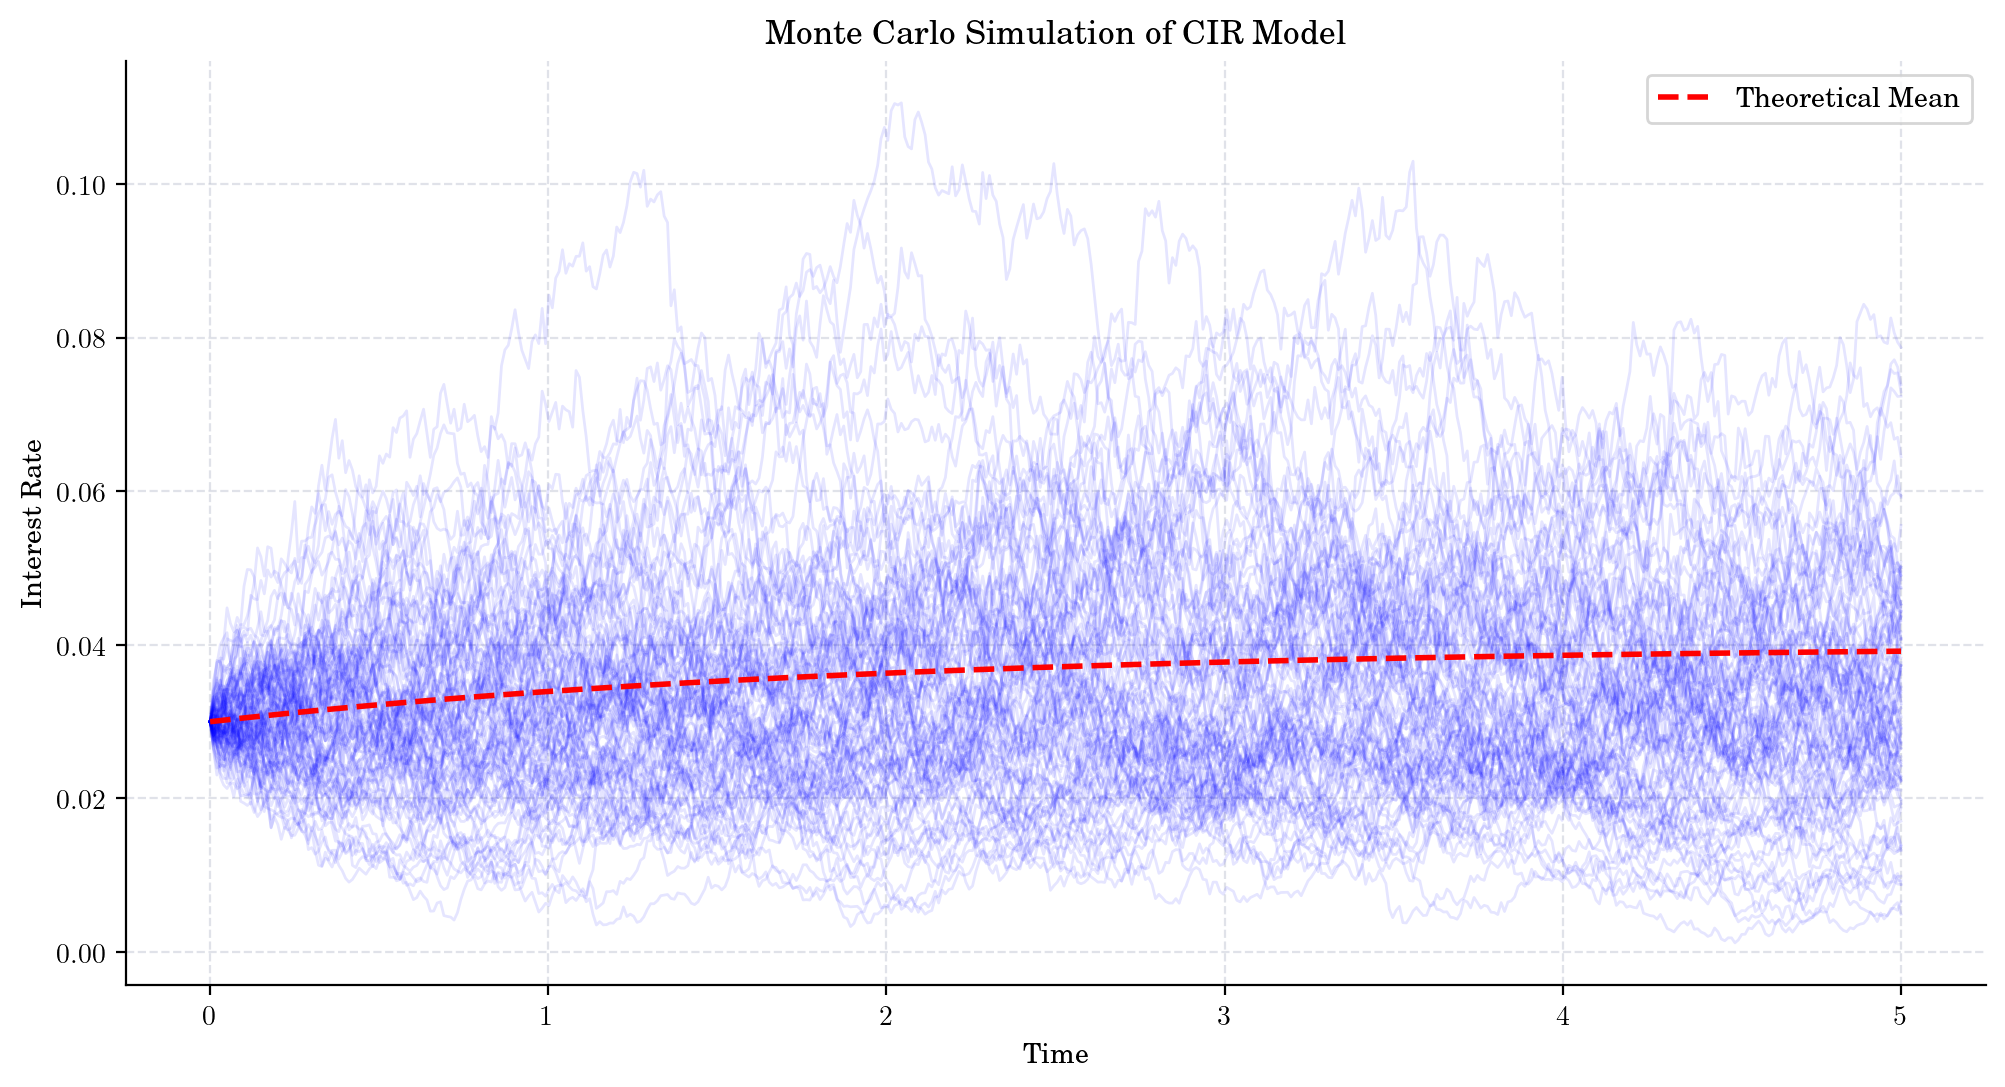

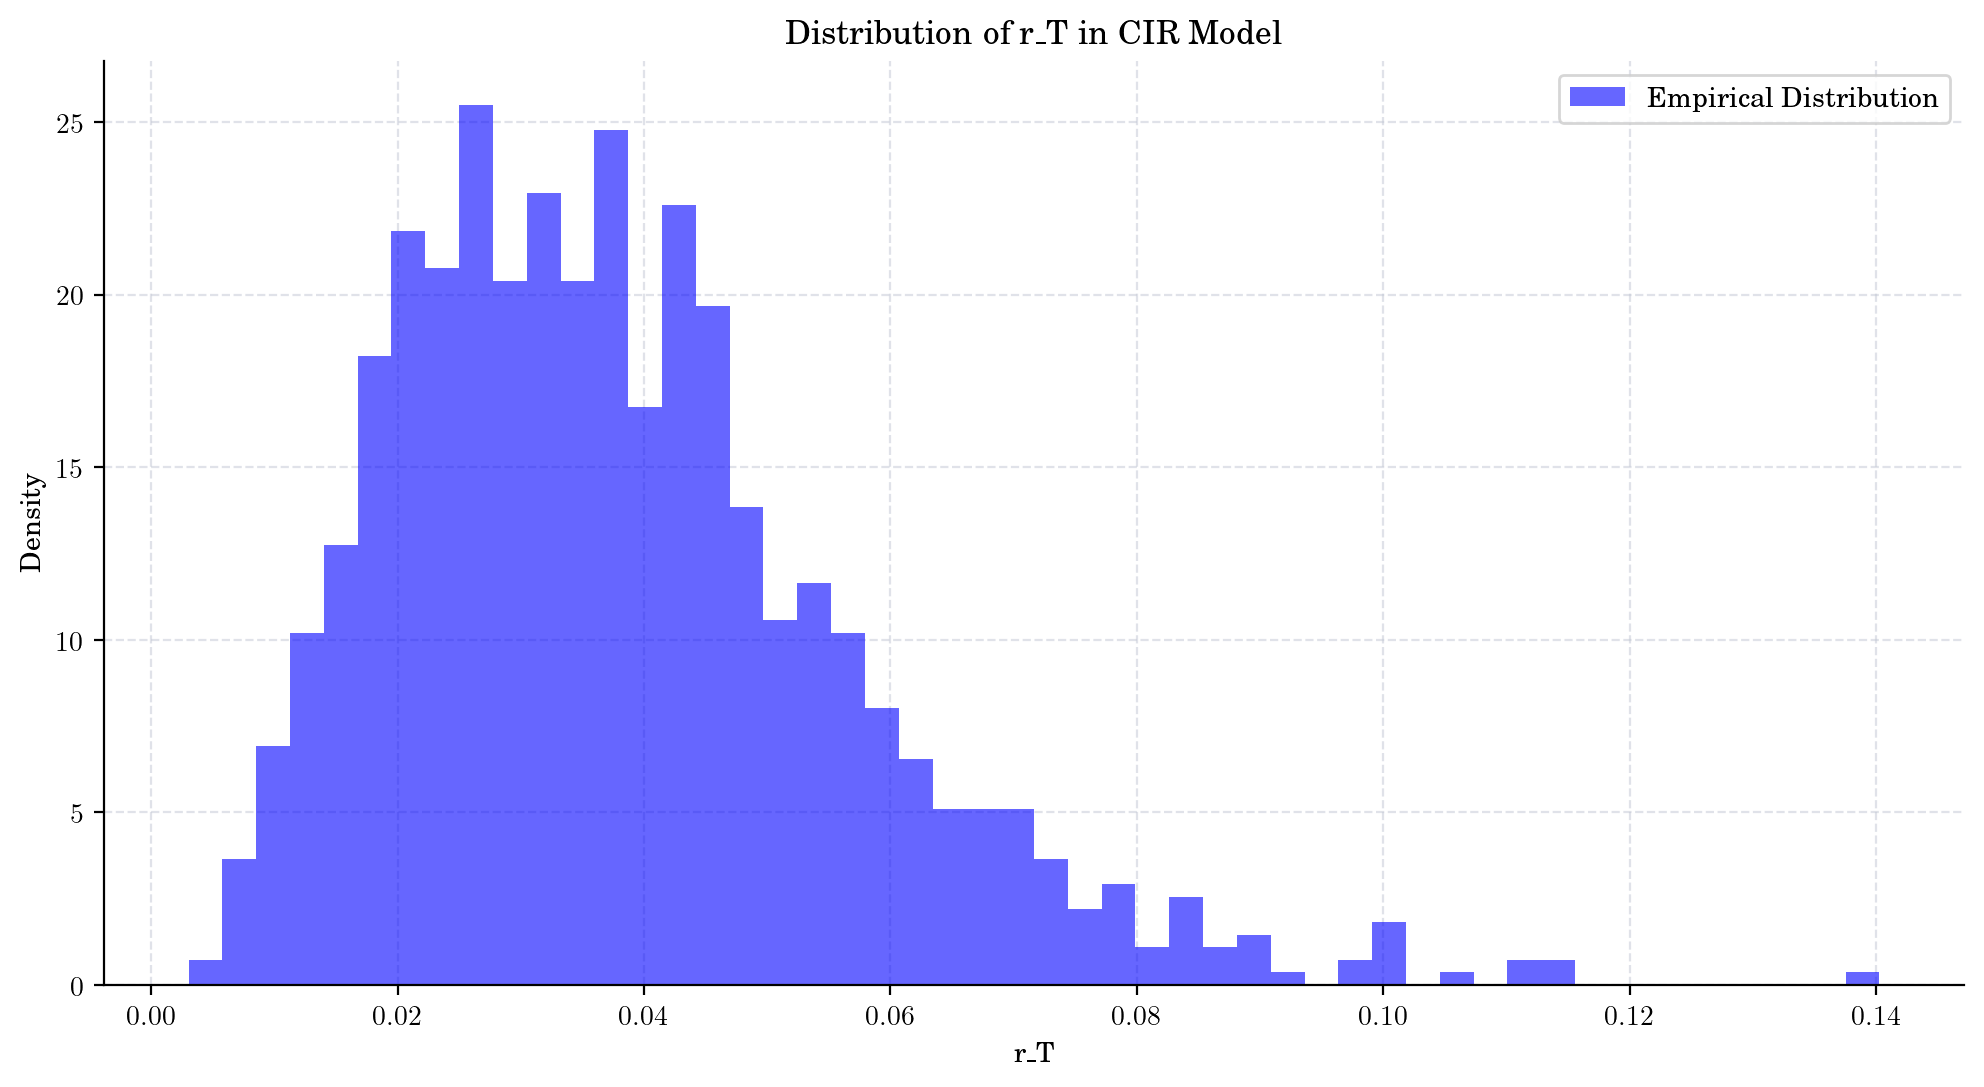

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# CIR Model Parameters
theta = 0.5     # Speed of mean reversion
mu = 0.04       # Long-term mean interest rate
sigma = 0.1     # Volatility
r0 = 0.03       # Initial interest rate
dt = 0.01       # Time step
T = 5.0         # Total time in years
N = int(T / dt) # Number of time steps
M = 1000        # Number of simulations

# Time grid
t = np.linspace(0, T, N)

# Initialize paths
r = np.zeros((M, N))
r[:, 0] = r0

# Generate random noise
dW = np.sqrt(dt) * np.random.randn(M, N)

# Euler-Maruyama Method for CIR SDE
for i in range(1, N):
    r[:, i] = r[:, i-1] + theta * (mu - r[:, i-1]) * dt + sigma * np.sqrt(np.maximum(r[:, i-1], 0)) * dW[:, i]

# Theoretical Mean and Variance
mean_theoretical = mu + (r0 - mu) * np.exp(-theta * t)
variance_theoretical = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

# Plot Simulated Paths
plt.figure(figsize=(12, 6))
for i in range(100):  # Plot only 100 paths
    plt.plot(t, r[i, :], color='blue', alpha=0.1)
plt.plot(t, mean_theoretical, color='red', linestyle="--", linewidth=2, label="Theoretical Mean")
plt.xlabel("Time")
plt.ylabel("Interest Rate")
plt.title("Monte Carlo Simulation of CIR Model")
plt.legend()
plt.show()

# Histogram of r_T vs Theoretical Distribution
r_T = r[:, -1]
plt.figure(figsize=(12, 6))
plt.hist(r_T, bins=50, density=True, alpha=0.6, color="blue", label="Empirical Distribution")
plt.xlabel("r_T")
plt.ylabel("Density")
plt.title("Distribution of r_T in CIR Model")
plt.legend()
plt.show()